# Notebook 02: RNA Secondary Structure Prediction and Target Site Selection

## Aim
Predict the secondary structure of each candidate conserved region identified 
in notebook 01 and identify structurally accessible target sites suitable for 
toehold switch binding. Accessibility is assessed using per-nucleotide unpaired 
probability profiles computed by ViennaRNA across the full ensemble of possible 
RNA structures.

## Biological rationale
Conservation alone is insufficient for toehold switch target selection. A 
conserved region that is buried within a stable stem-loop structure in the 
native Xylella fastidiosa 16S rRNA will be physically inaccessible to the 
toehold overhang of the switch, resulting in poor switching efficiency 
regardless of sequence specificity. Structurally accessible regions, where 
nucleotides are predominantly single-stranded, allow efficient toehold binding 
and branch migration to initiate the ON state transition.

Per-nucleotide unpaired probability is calculated using the ViennaRNA partition 
function, which integrates over the full thermodynamic ensemble of possible 
structures rather than relying solely on the minimum free energy prediction. 
This provides a more robust measure of accessibility than dot-bracket notation 
alone.

A sliding window approach identifies candidate 30-nucleotide target sites 
within accessible conserved regions. Cross-strain accessibility is verified 
using RefSeq reference sequences to confirm that candidate sites are accessible 
in multiple Xylella fastidiosa strains, not only in the pauca reference used 
for primary analysis.

## Input
- results/candidate_regions.csv from notebook 01
- data/xylella_16S_aligned.fasta from notebook 01

## Output
- results/accessibility_profiles.png: per-nucleotide accessibility plots
- results/candidate_targets.csv: ranked candidate 30nt target sites

## 1. Setup and imports

In [1]:
# Standard library
import os
import sys

# ViennaRNA Python API
# Provides RNA secondary structure prediction and thermodynamic calculations
import RNA

# Biopython for sequence handling
from Bio import SeqIO

# Data handling and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Set up project paths
notebook_dir = os.path.dirname(os.path.abspath("02_structure_prediction.ipynb"))
project_root = os.path.dirname(notebook_dir)
data_dir = os.path.join(project_root, "data")
results_dir = os.path.join(project_root, "results")

print("Project root:", project_root)
print("Data directory:", data_dir)
print("Results directory:", results_dir)
print()
print("ViennaRNA version:", RNA.__version__)

Project root: /home/andre/xylella-toehold-biosensor
Data directory: /home/andre/xylella-toehold-biosensor/data
Results directory: /home/andre/xylella-toehold-biosensor/results

ViennaRNA version: 2.7.2


## 2. Load candidate regions from notebook 01

The candidate regions CSV produced in notebook 01 contains the alignment 
coordinates, raw sequences, sequence lengths, and GC content for all eight 
conserved regions. Regions R7 and R8 were flagged as excluded and borderline 
respectively. Only the six suitable regions are carried forward for structure 
prediction.

In [4]:
# Load candidate regions from notebook 01
csv_path = os.path.join(results_dir, "candidate_regions.csv")
regions_df = pd.read_csv(csv_path)

print(f"Loaded {len(regions_df)} candidate regions")
print()

# Explicitly select suitable regions by index
# R7 excluded as it has no sequence in the pauca reference
suitable_regions = regions_df[regions_df["region_id"].isin(
    ["R1", "R2", "R3", "R4", "R5", "R6", "R8"]
)].copy()

print(f"Regions carried forward: {len(suitable_regions)}")
print(suitable_regions[["region_id", "sequence_length", "gc_content"]].to_string(index=False))

Loaded 8 candidate regions

Regions carried forward: 7
region_id  sequence_length  gc_content
       R1               57        59.6
       R2              150        53.3
       R3              152        54.6
       R4              807        53.0
       R5               75        52.0
       R6              125        56.8
       R8               29        58.6


In [5]:
import subprocess
result = subprocess.run(
    ["cat", csv_path],
    capture_output=True,
    text=True
)
print(result.stdout[:500])

region_id,alignment_start,alignment_end,length_nt,sequence_length,sequence,gc_content
R1,98,155,57,57,GGGTGGCGAGTGGCGGACGGGTGAGGAATACATCGGAATCTACCTTATCGTGGGGGA,59.6
R2,156,306,150,150,AACGTAGGGAAACTTACGCTAATACCGCATACGACCTACGGGTGAAAGCAGGGGACCTTAGGGCCTTGTGCGATTGGATGAGCCGATGTCCGATTAGCTAGTTGGTGAGGTAAAGGCTCACCAAGGCGACGATCGGTAGCTGGTCTGAGA,53.3
R3,307,473,166,152,GATGATCAGCCACACTGGAACTGAGACACGGTCCAGACTCCTACGGGAGGCAGCAGTGGGGAATATTGGACAATGGGCGCAAGCCTGATCCAGCTATGCCGCGTGGGTGAAGAATGCCTTCGGGTTGTAAAGCCCTTTTGT


## 2. RNA secondary structure prediction using ViennaRNA

RNAfold from the ViennaRNA package is used to predict the secondary structure 
of each candidate region. Two calculations are performed for each sequence.

The first is the minimum free energy structure, which identifies the single 
most thermodynamically stable folding of the RNA. This is represented in 
dot-bracket notation where dots indicate unpaired nucleotides and brackets 
indicate base paired nucleotides.

The second is the partition function calculation, which computes the 
probability that each nucleotide is unpaired across the full thermodynamic 
ensemble of possible structures. This per-nucleotide unpaired probability 
is a more robust measure of accessibility than the minimum free energy 
structure alone, since RNA molecules are dynamic and sample multiple 
conformations in solution.

The DNA sequences from the candidate regions CSV are converted to RNA 
by replacing thymine with uracil before structure prediction.

In [7]:
def predict_structure(sequence, region_id):
    """
    Predict RNA secondary structure and compute per-nucleotide unpaired
    probability for a given sequence using ViennaRNA.
    
    Parameters
    ----------
    sequence : str
        RNA or DNA sequence to fold. Thymine is converted to uracil
        automatically before folding.
    region_id : str
        Identifier for the region, used in output messages only.
        
    Returns
    -------
    mfe_structure : str
        Dot-bracket notation of minimum free energy structure
    mfe : float
        Minimum free energy in kcal/mol
    unpaired_probs : np.array
        Per-nucleotide unpaired probability between 0 and 1
    """
    
    # Convert DNA to RNA by replacing T with U
    # ViennaRNA accepts both but explicit conversion is cleaner
    rna_sequence = sequence.upper().replace("T", "U")
    
    # Create RNA fold compound object
    # This is the central object in the ViennaRNA Python API
    fc = RNA.fold_compound(rna_sequence)
    
    # Calculate minimum free energy structure
    # Returns tuple of (dot-bracket structure, MFE value)
    mfe_structure, mfe = fc.mfe()
    
    # Calculate partition function
    # This populates the base pair probability matrix inside fc
    fc.pf()
    
    # Extract per-nucleotide unpaired probabilities
    # bp_stack returns base pair probabilities for all pairs
    # Unpaired probability at position i = 1 - sum of all pairing probabilities at i
    bpp = fc.bpp()
    seq_length = len(rna_sequence)
    unpaired_probs = np.ones(seq_length)
    
    for i in range(1, seq_length + 1):
        for j in range(i + 1, seq_length + 1):
            pair_prob = bpp[i][j]
            if pair_prob > 0:
                # Subtract pairing probability from both partners
                unpaired_probs[i-1] -= pair_prob
                unpaired_probs[j-1] -= pair_prob
    
    # Clip to valid range in case of floating point errors
    unpaired_probs = np.clip(unpaired_probs, 0, 1)
    
    print(f"{region_id}: MFE = {mfe:.2f} kcal/mol, "
          f"mean unpaired probability = {unpaired_probs.mean():.3f}")
    
    return mfe_structure, mfe, unpaired_probs

In [8]:
# Run structure prediction for all suitable regions
# Store results in a dictionary keyed by region_id

structure_results = {}

print("Running ViennaRNA structure prediction...")
print()

for _, row in suitable_regions.iterrows():
    region_id = row["region_id"]
    sequence = row["sequence"]
    
    # Skip if sequence is empty or too short
    if not isinstance(sequence, str) or len(sequence) < 10:
        print(f"{region_id}: skipped (sequence too short or missing)")
        continue
    
    mfe_structure, mfe, unpaired_probs = predict_structure(sequence, region_id)
    
    structure_results[region_id] = {
        "sequence": sequence,
        "rna_sequence": sequence.upper().replace("T", "U"),
        "mfe_structure": mfe_structure,
        "mfe": mfe,
        "unpaired_probs": unpaired_probs,
        "mean_accessibility": unpaired_probs.mean()
    }

print()
print("Structure prediction complete.")
print()
print(f"{'Region':<8} {'Length':<8} {'MFE (kcal/mol)':<18} {'Mean accessibility'}")
print("-" * 55)
for region_id, result in structure_results.items():
    print(f"{region_id:<8} {len(result['sequence']):<8} "
          f"{result['mfe']:<18.2f} {result['mean_accessibility']:.3f}")

Running ViennaRNA structure prediction...

R1: MFE = -11.20 kcal/mol, mean unpaired probability = 0.501
R2: MFE = -52.10 kcal/mol, mean unpaired probability = 0.385
R3: MFE = -47.90 kcal/mol, mean unpaired probability = 0.432
R4: MFE = -283.30 kcal/mol, mean unpaired probability = 0.366
R5: MFE = -17.40 kcal/mol, mean unpaired probability = 0.552
R6: MFE = -33.60 kcal/mol, mean unpaired probability = 0.429
R8: MFE = -7.10 kcal/mol, mean unpaired probability = 0.484

Structure prediction complete.

Region   Length   MFE (kcal/mol)     Mean accessibility
-------------------------------------------------------
R1       57       -11.20             0.501
R2       150      -52.10             0.385
R3       152      -47.90             0.432
R4       807      -283.30            0.366
R5       75       -17.40             0.552
R6       125      -33.60             0.429
R8       29       -7.10              0.484


## 2a. Structure prediction results

ViennaRNA structure prediction was run on all seven suitable candidate regions. 
Results are summarised below.

Region   Length   MFE (kcal/mol)   Mean accessibility
R1       57       -11.20           0.501
R2       150      -52.10           0.385
R3       152      -47.90           0.432
R4       807      -283.30          0.366
R5       75       -17.40           0.552
R6       125      -33.60           0.429
R8       29       -7.10            0.484

R5 shows the highest mean accessibility at 0.552, making it the most 
promising region overall. R1 and R8 are also relatively accessible but 
R8 has limited sequence length for target window selection.

MFE values reflect sequence length and cannot be compared directly across 
regions of different lengths. R4 has the most negative MFE at -283.30 
kcal/mol consistent with its length of 807 nucleotides, but may still 
contain locally accessible windows. Mean accessibility alone is not 
sufficient for target selection. Per-nucleotide accessibility profiles 
and sliding window analysis are required to identify optimal 30-nucleotide 
target sites within each region.

## 3. Accessibility profile visualisation

Per-nucleotide unpaired probability is plotted for each region. The 
accessibility threshold of 0.5 is shown as a reference line. Consecutive 
stretches above this threshold are the most promising locations for 
toehold switch target sites. The minimum free energy structure in 
dot-bracket notation is shown below each plot for reference.

## 3a. Accessibility profile interpretation

Per-nucleotide unpaired probability profiles reveal that accessibility 
varies considerably across and within candidate regions.

R5 shows the most promising accessibility profile with a large continuously 
accessible block from approximately position 30 to 75, sitting consistently 
above the 0.5 threshold throughout. This region is the highest priority 
candidate for target window selection.

R2 and R3 both show strong accessible blocks in their central portions 
roughly between positions 60 and 120, with less accessible ends. Both 
are good candidates for target window selection.

R1 shows mixed accessibility with accessible windows at the sequence 
termini and less accessible central positions.

R4 shows a noisy oscillating profile consistent with complex folding of 
a long 807 nucleotide sequence. Locally accessible windows are likely 
present and will be identified by sliding window analysis.

R6 shows mixed accessibility with moderate peaks above threshold but 
also significant dips, making it a lower priority candidate.

R8 is borderline with a single accessible block but insufficient length 
for reliable 30 nucleotide window selection.

Priority order for sliding window analysis based on accessibility profiles:
R5 > R2 > R3 > R1 > R6 > R4 > R8

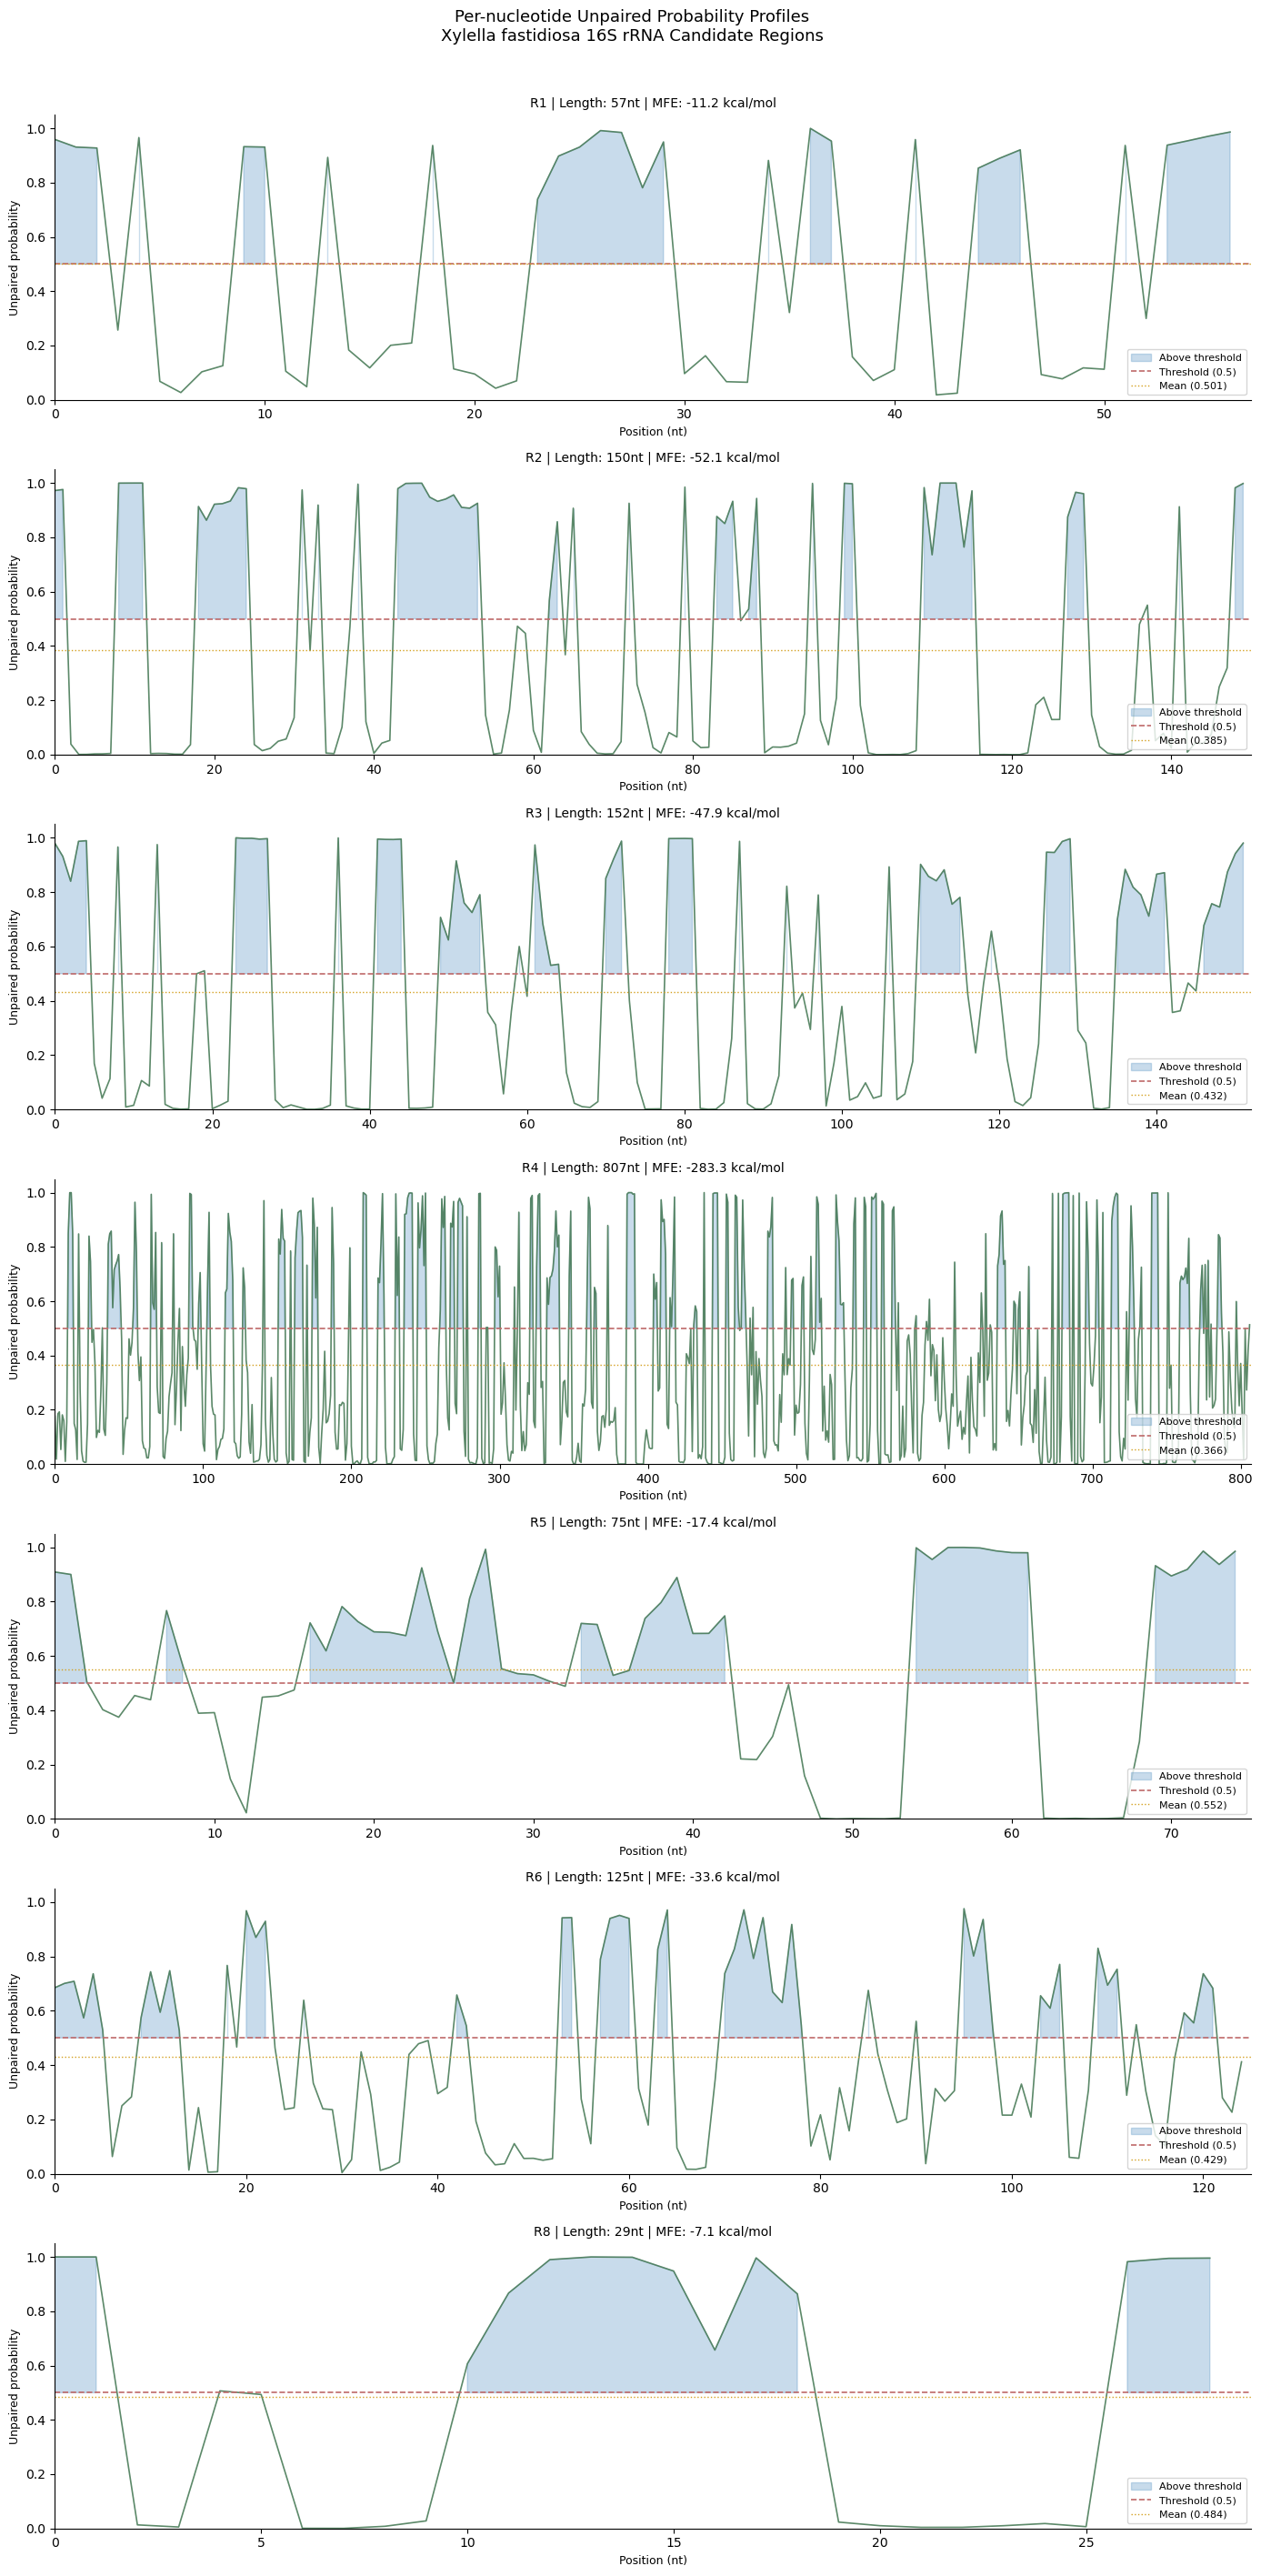

Accessibility profiles saved to /home/andre/xylella-toehold-biosensor/results/accessibility_profiles.png


In [9]:
def plot_accessibility(region_id, result, ax, threshold=0.5):
    """
    Plot per-nucleotide unpaired probability profile for a single region.
    
    Parameters
    ----------
    region_id : str
        Region identifier for the plot title
    result : dict
        Structure prediction result from predict_structure
    ax : matplotlib axis
        Axis to plot on
    threshold : float
        Accessibility threshold line to display
    """
    
    unpaired_probs = result["unpaired_probs"]
    positions = np.arange(len(unpaired_probs))
    
    # Plot accessibility profile
    ax.plot(
        positions,
        unpaired_probs,
        color="#4a7c59",
        linewidth=1.2,
        alpha=0.9
    )
    
    # Fill area above threshold in blue to highlight accessible regions
    ax.fill_between(
        positions,
        unpaired_probs,
        threshold,
        where=unpaired_probs >= threshold,
        alpha=0.3,
        color="#4a8abf",
        label="Above threshold"
    )
    
    # Threshold line
    ax.axhline(
        y=threshold,
        color="#bf6a6a",
        linewidth=1.2,
        linestyle="--",
        label=f"Threshold ({threshold})"
    )
    
    # Mean accessibility line
    ax.axhline(
        y=result["mean_accessibility"],
        color="#d4a020",
        linewidth=1.0,
        linestyle=":",
        label=f"Mean ({result['mean_accessibility']:.3f})"
    )
    
    ax.set_title(
        f"{region_id} | Length: {len(result['sequence'])}nt | "
        f"MFE: {result['mfe']:.1f} kcal/mol",
        fontsize=10
    )
    ax.set_xlabel("Position (nt)", fontsize=9)
    ax.set_ylabel("Unpaired probability", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, len(unpaired_probs))
    ax.legend(fontsize=8, loc="lower right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Create figure with one subplot per region
n_regions = len(structure_results)
fig, axes = plt.subplots(
    n_regions, 1,
    figsize=(14, 4 * n_regions)
)

# Handle case of single region
if n_regions == 1:
    axes = [axes]

for ax, (region_id, result) in zip(axes, structure_results.items()):
    plot_accessibility(region_id, result, ax, threshold=0.5)

plt.suptitle(
    "Per-nucleotide Unpaired Probability Profiles\n"
    "Xylella fastidiosa 16S rRNA Candidate Regions",
    fontsize=13,
    y=1.01
)

plt.tight_layout()

# Save figure
plot_path = os.path.join(results_dir, "accessibility_profiles.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Accessibility profiles saved to {plot_path}")

## 4. Sliding window accessibility analysis

A sliding window of 30 nucleotides is moved across each candidate region 
one position at a time. At each position the mean unpaired probability 
across all 30 nucleotides in the window is calculated. Windows where the 
mean unpaired probability exceeds 0.5 are flagged as accessible candidate 
target sites.

A window size of 30 nucleotides is used consistent with the trigger RNA 
length used by Pardee et al. (2016) and the minimum toehold domain length 
recommended by Green et al. (2014) for naturally folded RNA targets.

Windows are ranked by mean accessibility score within each region. The 
top three windows per region are carried forward for cross-strain 
accessibility verification in section 5.

In [ ]:
def sliding_window_accessibility(unpaired_probs, sequence, window_size=30, 
                                  threshold=0.5):
    """
    Identify accessible target windows using a sliding window approach.
    
    Parameters
    ----------
    unpaired_probs : np.array
        Per-nucleotide unpaired probability from predict_structure
    sequence : str
        Raw nucleotide sequence corresponding to unpaired_probs
    window_size : int
        Length of sliding window in nucleotides. Default 30 as per
        Green et al. (2014) recommendation for mRNA-sensing switches.
    threshold : float
        Minimum mean unpaired probability for a window to be flagged
        as accessible. Default 0.5.
        
    Returns
    -------
    windows_df : pandas DataFrame
        All windows above threshold ranked by mean accessibility score,
        containing start, end, sequence, mean accessibility, and GC content
    """
    
    seq_length = len(unpaired_probs)
    windows = []
    
    # Slide window across the full sequence one position at a time
    for start in range(seq_length - window_size + 1):
        end = start + window_size
        
        # Extract unpaired probabilities for this window
        window_probs = unpaired_probs[start:end]
        mean_accessibility = window_probs.mean()
        
        # Only retain windows above the accessibility threshold
        if mean_accessibility >= threshold:
            window_seq = sequence[start:end].upper().replace("T", "U")
            
            # Calculate GC content of this window
            gc = (window_seq.count("G") + window_seq.count("C")) / len(window_seq)
            
            windows.append({
                "window_start": start,
                "window_end": end,
                "sequence": window_seq,
                "mean_accessibility": round(mean_accessibility, 4),
                "min_accessibility": round(window_probs.min(), 4),
                "gc_content": round(gc * 100, 1)
            })
    
    if len(windows) == 0:
        return pd.DataFrame()
    
    # Convert to dataframe and rank by mean accessibility
    windows_df = pd.DataFrame(windows)
    windows_df = windows_df.sort_values(
        "mean_accessibility", ascending=False
    ).reset_index(drop=True)
    
    return windows_df


# Run sliding window analysis for all regions
all_windows = {}

print("Sliding window accessibility analysis (window=30nt, threshold=0.5)")
print()

for region_id, result in structure_results.items():
    windows_df = sliding_window_accessibility(
        result["unpaired_probs"],
        result["sequence"],
        window_size=30,
        threshold=0.5
    )
    
    all_windows[region_id] = windows_df
    
    if len(windows_df) == 0:
        print(f"{region_id}: no windows above threshold")
    else:
        print(f"{region_id}: {len(windows_df)} windows above threshold")
        print(f"  Top window: position {windows_df.iloc[0]['window_start']}-"
              f"{windows_df.iloc[0]['window_end']}, "
              f"accessibility={windows_df.iloc[0]['mean_accessibility']:.4f}, "
              f"GC={windows_df.iloc[0]['gc_content']}%")
        print(f"  Sequence: {windows_df.iloc[0]['sequence']}")
    print()

## 4a. Sliding window analysis results

Sliding window analysis identified accessible 30-nucleotide target windows 
in six of the seven candidate regions. R8 produced no windows above the 
0.5 threshold, confirming its unsuitability for toehold switch design.

Summary of accessible windows per region:

Region   Windows   Top accessibility   Top window position   GC%
R1       9         0.5252              26-56                 46.7
R2       20        0.5441              36-66                 60.0
R3       11        0.5663              122-152               43.3
R4       17        0.5393              245-275               53.3
R5       31        0.6621              13-43                 50.0
R6       13        0.5468              53-83                 60.0
R8       0         -                   -                     -

R5 is the highest priority candidate with 31 accessible windows and a 
top accessibility score of 0.6621, the highest across all regions. The 
top window sequence GAGCUAAUCCCAGAAACCCUAUCUCAGUCC at position 13-43 
is the primary candidate target site for toehold switch design.

R3 is the second highest priority with a top window score of 0.5663. 
R2 and R6 show good accessibility but their top windows have relatively 
high GC content of 60%, which requires monitoring during switch design. 
R1 and R4 are lower priority candidates.

The top three windows from each suitable region are carried forward for 
cross-strain accessibility verification in section 5.

In [11]:
# Extract top three windows from each suitable region
# These will be verified for accessibility in other Xylella fastidiosa strains

top_windows = {}

print("Top 3 accessible windows per region")
print()

for region_id, windows_df in all_windows.items():
    if len(windows_df) == 0:
        print(f"{region_id}: no suitable windows")
        continue
    
    # Take top 3 by accessibility score
    top3 = windows_df.head(3).copy()
    top3["region_id"] = region_id
    top_windows[region_id] = top3
    
    print(f"{region_id}:")
    for _, row in top3.iterrows():
        print(f"  pos {row['window_start']}-{row['window_end']} | "
              f"accessibility={row['mean_accessibility']:.4f} | "
              f"GC={row['gc_content']}% | "
              f"{row['sequence']}")
    print()

Top 3 accessible windows per region

R1:
  pos 26-56 | accessibility=0.5252 | GC=46.7% | AAUACAUCGGAAUCUACCUUAUCGUGGGGG
  pos 27-57 | accessibility=0.5250 | GC=46.7% | AUACAUCGGAAUCUACCUUAUCGUGGGGGA
  pos 25-55 | accessibility=0.5238 | GC=46.7% | GAAUACAUCGGAAUCUACCUUAUCGUGGGG

R2:
  pos 36-66 | accessibility=0.5441 | GC=60.0% | UACGGGUGAAAGCAGGGGACCUUAGGGCCU
  pos 37-67 | accessibility=0.5435 | GC=60.0% | ACGGGUGAAAGCAGGGGACCUUAGGGCCUU
  pos 21-51 | accessibility=0.5322 | GC=53.3% | AUACCGCAUACGACCUACGGGUGAAAGCAG

R3:
  pos 122-152 | accessibility=0.5663 | GC=43.3% | GGUUGUAAAGCCCUUUUGUUGGGGAAGAAA
  pos 121-151 | accessibility=0.5397 | GC=46.7% | GGGUUGUAAAGCCCUUUUGUUGGGGAAGAA
  pos 110-140 | accessibility=0.5355 | GC=46.7% | AGAAUGCCUUCGGGUUGUAAAGCCCUUUUG

R4:
  pos 245-275 | accessibility=0.5393 | GC=53.3% | GUAGAGAUCAGGAGGAACAUCCGUGGCGAA
  pos 246-276 | accessibility=0.5389 | GC=53.3% | UAGAGAUCAGGAGGAACAUCCGUGGCGAAG
  pos 236-266 | accessibility=0.5321 | GC=46.7% | GUGAAAUGCGUAGAG

## 5. Cross-strain accessibility verification

The top three windows identified in the pauca reference sequence are 
verified for accessibility in two additional Xylella fastidiosa reference 
sequences. The RefSeq sequences NR_115924.1 and NR_041783.1 are used, 
representing X. fastidiosa strain ATCC 35879 and X. fastidiosa subsp. 
multiplex strain PL.788 respectively. These are curated reference sequences 
and represent diversity across the species.

For each candidate window the corresponding region in each reference 
sequence is located by searching for the window sequence or its closest 
match, and the mean unpaired probability at that position is calculated. 
A window is confirmed as cross-strain accessible if its mean accessibility 
exceeds 0.5 in both reference sequences.

In [12]:
# Load the aligned sequences to extract cross-strain reference sequences
aligned_fasta_path = os.path.join(data_dir, "xylella_16S_aligned.fasta")
alignment = list(SeqIO.parse(aligned_fasta_path, "fasta"))

# Identify the two RefSeq reference sequences for cross-strain check
# NR_115924.1: X. fastidiosa strain ATCC 35879 (full length 1537nt)
# NR_041783.1: X. fastidiosa subsp. multiplex strain PL.788 (full length 1533nt)
refseq_ids = ["NR_115924.1", "NR_041783.1"]
refseq_records = {}

for rec in alignment:
    for ref_id in refseq_ids:
        if ref_id in rec.id:
            # Remove gap characters to get raw sequence
            raw_seq = str(rec.seq).replace("-", "").upper()
            refseq_records[ref_id] = raw_seq
            print(f"Found: {rec.id} ({len(raw_seq)}nt)")

print(f"\nReference sequences loaded: {len(refseq_records)}")

Found: NR_041783.1 (1533nt)
Found: NR_115924.1 (1537nt)

Reference sequences loaded: 2


In [13]:
# Run structure prediction on both reference sequences
# Then locate each candidate window by sequence matching
# and calculate accessibility at that position

print("Running structure prediction on reference sequences...")
print()

refseq_structures = {}

for ref_id, sequence in refseq_records.items():
    print(f"Predicting structure for {ref_id} ({len(sequence)}nt)...")
    mfe_structure, mfe, unpaired_probs = predict_structure(sequence, ref_id)
    refseq_structures[ref_id] = {
        "sequence": sequence,
        "rna_sequence": sequence.replace("T", "U"),
        "mfe_structure": mfe_structure,
        "mfe": mfe,
        "unpaired_probs": unpaired_probs
    }
    print()

print("Structure prediction complete for reference sequences.")

Running structure prediction on reference sequences...

Predicting structure for NR_041783.1 (1533nt)...
NR_041783.1: MFE = -570.50 kcal/mol, mean unpaired probability = 0.364

Predicting structure for NR_115924.1 (1537nt)...
NR_115924.1: MFE = -565.90 kcal/mol, mean unpaired probability = 0.360

Structure prediction complete for reference sequences.


In [14]:
def find_window_in_sequence(window_seq, target_sequence, window_size=30):
    """
    Locate a candidate window sequence within a target reference sequence
    using exact matching first, then allowing for minor mismatches.
    
    Parameters
    ----------
    window_seq : str
        The 30nt window sequence to search for, in RNA format
    target_sequence : str
        The reference sequence to search within, in RNA format
    window_size : int
        Window size in nucleotides
        
    Returns
    -------
    best_start : int or None
        Start position of best match in target sequence, None if not found
    best_score : float
        Identity score of best match between 0 and 1
    """
    
    # Convert both to RNA uppercase for comparison
    window_rna = window_seq.upper().replace("T", "U")
    target_rna = target_sequence.upper().replace("T", "U")
    
    best_start = None
    best_score = 0
    
    # Slide across target sequence looking for best match
    for start in range(len(target_rna) - window_size + 1):
        candidate = target_rna[start:start + window_size]
        
        # Calculate identity score
        matches = sum(a == b for a, b in zip(window_rna, candidate))
        score = matches / window_size
        
        if score > best_score:
            best_score = score
            best_start = start
    
    # Only return match if identity is above 80%
    if best_score < 0.80:
        return None, best_score
    
    return best_start, best_score


# Cross-strain accessibility verification
# For each top window check accessibility in both reference sequences

print("Cross-strain accessibility verification")
print(f"{'Region':<6} {'Window':<12} {'Pauca acc':<12} "
      f"{'NR_041783':<12} {'NR_115924':<12} {'Confirmed'}")
print("-" * 70)

cross_strain_results = []

for region_id, windows_df in top_windows.items():
    for _, row in windows_df.iterrows():
        window_seq = row["sequence"]
        pauca_acc = row["mean_accessibility"]
        window_pos = f"{row['window_start']}-{row['window_end']}"
        
        ref_accessibilities = {}
        confirmed = True
        
        for ref_id, ref_data in refseq_structures.items():
            # Locate window in reference sequence
            best_start, identity = find_window_in_sequence(
                window_seq,
                ref_data["sequence"]
            )
            
            if best_start is None:
                ref_acc = 0.0
                confirmed = False
            else:
                # Calculate mean accessibility at this position
                ref_acc = ref_data["unpaired_probs"][
                    best_start:best_start + 30
                ].mean()
                
                if ref_acc < 0.5:
                    confirmed = False
            
            ref_accessibilities[ref_id] = round(ref_acc, 4)
        
        cross_strain_results.append({
            "region_id": region_id,
            "window_position": window_pos,
            "sequence": window_seq,
            "pauca_accessibility": round(pauca_acc, 4),
            "NR_041783_accessibility": ref_accessibilities.get("NR_041783.1", 0),
            "NR_115924_accessibility": ref_accessibilities.get("NR_115924.1", 0),
            "cross_strain_confirmed": confirmed,
            "gc_content": row["gc_content"]
        })
        
        confirmed_str = "YES" if confirmed else "NO"
        print(f"{region_id:<6} {window_pos:<12} {pauca_acc:<12.4f} "
              f"{ref_accessibilities.get('NR_041783.1', 0):<12.4f} "
              f"{ref_accessibilities.get('NR_115924.1', 0):<12.4f} "
              f"{confirmed_str}")

print()
cross_strain_df = pd.DataFrame(cross_strain_results)
confirmed_count = cross_strain_df["cross_strain_confirmed"].sum()
print(f"Windows confirmed across all three strains: {confirmed_count} "
      f"out of {len(cross_strain_df)}")

Cross-strain accessibility verification
Region Window       Pauca acc    NR_041783    NR_115924    Confirmed
----------------------------------------------------------------------
R1     26-56        0.5252       0.3015       0.4062       NO
R1     27-57        0.5250       0.3060       0.4107       NO
R1     25-55        0.5238       0.2971       0.3855       NO
R2     36-66        0.5441       0.4430       0.4745       NO
R2     37-67        0.5435       0.4191       0.4503       NO
R2     21-51        0.5322       0.4484       0.5132       NO
R3     122-152      0.5663       0.4320       0.4507       NO
R3     121-151      0.5397       0.4144       0.4237       NO
R3     110-140      0.5355       0.4035       0.4129       NO
R4     245-275      0.5393       0.5394       0.5389       YES
R4     246-276      0.5389       0.5390       0.5382       YES
R4     236-266      0.5321       0.5321       0.5328       YES
R5     13-43        0.6621       0.5303       0.3787       NO
R5     14-4

## 5a. Cross-strain accessibility verification results

Cross-strain accessibility verification revealed that only three windows, 
all from region R4, were confirmed accessible above the 0.5 threshold 
across all three strains tested. These three windows at positions 245-275, 
246-276, and 236-266 showed remarkable consistency across pauca, 
NR_041783, and NR_115924 with accessibility scores varying by less than 
0.001 between strains, strongly suggesting this is a genuinely accessible 
region in Xylella fastidiosa 16S rRNA generally.

R5 showed exceptional accessibility in the pauca reference at 0.66 but 
dropped below threshold in NR_115924 at 0.38, suggesting strain-specific 
structural differences at this region. R5 windows are retained as secondary 
candidates and may be revisited if R4-based switch designs do not perform 
well experimentally.

R6 dropped dramatically in both reference strains to approximately 0.22 
to 0.27, indicating a strongly conserved stem loop structure in most 
strains with the pauca accessibility likely representing an outlier.

R1, R2, and R3 approached but did not reach the cross-strain threshold, 
with R2 position 21-51 coming closest at 0.5132 in NR_115924 but 0.4484 
in NR_041783.

Primary candidates carried forward to notebook 03: R4 positions 245-275, 
246-276, and 236-266.
Secondary candidates retained for reference: R5 positions 13-43, 14-44, 
and 15-45.

In [15]:
# Compile final ranked candidate target table
# Primary candidates: R4 windows confirmed across all three strains
# Secondary candidates: R5 windows retained for reference

# Separate confirmed and secondary candidates
primary_candidates = cross_strain_df[
    cross_strain_df["cross_strain_confirmed"] == True
].copy()

secondary_candidates = cross_strain_df[
    cross_strain_df["region_id"] == "R5"
].copy()
secondary_candidates["cross_strain_confirmed"] = "SECONDARY"

# Combine into final table
final_candidates = pd.concat(
    [primary_candidates, secondary_candidates],
    ignore_index=True
)

# Add rank column
final_candidates["rank"] = range(1, len(final_candidates) + 1)

# Reorder columns for clarity
final_candidates = final_candidates[[
    "rank",
    "region_id",
    "window_position",
    "sequence",
    "pauca_accessibility",
    "NR_041783_accessibility",
    "NR_115924_accessibility",
    "cross_strain_confirmed",
    "gc_content"
]]

print("Final ranked candidate target sites")
print()
print(final_candidates.to_string(index=False))
print()

# Save to CSV for notebook 03
targets_path = os.path.join(results_dir, "candidate_targets.csv")
final_candidates.to_csv(targets_path, index=False)
print(f"Saved to {targets_path}")

Final ranked candidate target sites

 rank region_id window_position                       sequence  pauca_accessibility  NR_041783_accessibility  NR_115924_accessibility cross_strain_confirmed  gc_content
    1        R4         245-275 GUAGAGAUCAGGAGGAACAUCCGUGGCGAA               0.5393                   0.5394                   0.5389                   True        53.3
    2        R4         246-276 UAGAGAUCAGGAGGAACAUCCGUGGCGAAG               0.5389                   0.5390                   0.5382                   True        53.3
    3        R4         236-266 GUGAAAUGCGUAGAGAUCAGGAGGAACAUC               0.5321                   0.5321                   0.5328                   True        46.7
    4        R5           13-43 GAGCUAAUCCCAGAAACCCUAUCUCAGUCC               0.6621                   0.5303                   0.3787              SECONDARY        50.0
    5        R5           14-44 AGCUAAUCCCAGAAACCCUAUCUCAGUCCG               0.6545                   0.5211          

## 6. Summary and next steps

Notebook 02 has completed the following.

1. Loaded six suitable candidate conserved regions from notebook 01 and 
   predicted RNA secondary structure for each using ViennaRNA 2.7.2, 
   calculating both minimum free energy structures and per-nucleotide 
   unpaired probability profiles via partition function calculation.

2. Visualised per-nucleotide accessibility profiles for all seven regions, 
   identifying R5 as the most accessible overall and R4 as containing a 
   consistently accessible central domain.

3. Applied sliding window analysis with a 30-nucleotide window and 0.5 
   accessibility threshold, identifying accessible target windows in six 
   of seven regions. R8 produced no windows above threshold confirming 
   its unsuitability.

4. Performed cross-strain accessibility verification using two curated 
   RefSeq reference sequences representing X. fastidiosa subsp. multiplex 
   and X. fastidiosa strain ATCC 35879. Only R4 windows were confirmed 
   accessible above 0.5 in all three strains.

5. Compiled a final ranked candidate target table containing three primary 
   candidates from R4 and three secondary candidates from R5.

Output files produced:
- results/accessibility_profiles.png: per-nucleotide accessibility plots
- results/candidate_targets.csv: six ranked candidate target sites

Primary candidates for notebook 03:
- R4 position 245-275: GUAGAGAUCAGGAGGAACAUCCGUGGCGAA (accessibility 0.5393)
- R4 position 246-276: UAGAGAUCAGGAGGAACAUCCGUGGCGAAG (accessibility 0.5389)
- R4 position 236-266: GUGAAAUGCGUAGAGAUCAGGAGGAACAUC (accessibility 0.5321)

These three R4 windows feed into notebook 03 where NUPACK will be used 
to design toehold switch sequences complementary to each target site and 
model the thermodynamic ensemble of the switch in its OFF and ON states.